# Filter Sandbox

This notebook is used as a sandbox playground and simulation environment to see how the IIR and FIR filters corrrect different kinds of signals and to test their code.

## Linear LS Filter Finder
------------------------

This code section allows the user to decide one of three type of system distortion effects. A step pulse is played and the distorted output is shown. The user can then select the number of 
feedforward and feedback taps to be found that will correct for the distortion. The values are found using linear LS. This predistorted pulse is shown followed by the output pulse after predistortion and system distortion.

This is the most sensible model in this notebook. The others are a sandbox environment that were testing different things.

### Initialising
------------------------

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, ifft, fftfreq
from scipy.signal import savgol_filter, lfilter, gausspulse
from scipy.optimize import curve_fit

### Dark Mode
-------------------------

In [87]:
### Run this cell only if you're using "dark mode"

# svg plots (higher res)
import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('png')

plt.rcParams.update({
    'figure.facecolor': '#383838',
    'figure.edgecolor': '#383838',
    'axes.facecolor':   '#383838',
    'axes.edgecolor':   '#DDE2F4',
    'axes.labelcolor':  '#DDE2F4',
    'xtick.color':      '#DDE2F4',
    'ytick.color':      '#DDE2F4',
    'text.color':       '#DDE2F4',
    'axes.spines.right': False,
    'axes.spines.top':   False,
    'axes.titleweight': 'bold',
    'axes.labelweight': 'bold',
})

### Input Pulse
-------------------------

In [143]:
def input_pulse(time):
    """
    This function generates the input pulse that is played. The default option is a square pulse that exists for 60% of the time specified.

    Parameters
    -------------------
    time : array (real)
        The timeframe that the simulation environment exists for.

    Returns
    -------------------
    square_pulse : array (real)
        The square BB pulse that is treated as the input step signal for the system.
    """

    start_time = int(len(time) * 0.25) # to see the distortion effects and rise/fall, the pulse is shown for 50% of the entire timeframe specified
    square_pulse = np.zeros(len(time))
    amplitude = 1.0
    square_pulse[start_time:-start_time] = amplitude
    noise = 0.005
    square_pulse += np.random.normal(0, amplitude * noise, square_pulse.shape)

    plt.plot(time * 1e3, square_pulse, label = 'Input Pulse')
    plt.xlabel("Time [ms]")
    plt.ylabel("Amplitude [a.u]")
    plt.title("Input Pulse For System")
    #plt.grid(True)
    plt.legend()
    plt.show()

    # if one wishes to test a Gaussian input pulse instead...
    """gauss_time = time - (time[-1] / 2)
    gaussian = gausspulse(gauss_time, fc = 20)

    plt.plot(time * 1e3, gaussian, label = "Input Pulse")
    plt.xlabel("Time [ms]")
    plt.ylabel("Amplitude [a.u]")
    plt.title("Input Pulse For System")
    #plt.grid(True)
    plt.legend()
    plt.show()"""

    return square_pulse

### System Distortion Types
--------------------------------

In [3]:
def high_pass_compensation(time, delta_t, input):
    """
    This creates the high-pass distortion effect akin to what is found in bias-tees. Namely, a decaying exponential.

    Parameters
    -------------------
    time : array (real)
        The timeframe that the simulation environment exists for.

    delta_t : float (real)
        The resolution spacing between each time step of the simulation.

    input: array (real)
        The input step response to the system that will become distorted.

    Returns
    -------------------
    distorted_output : array (real)
        The distorted pulse after applying the system distortion.
    
    system_zeros : array (real)
        The 'b' coefficients that describe the 'zeros' of the system.

    system_poles : array (real)
        The 'a' coefficients that describe the 'poles' of the system.
    """

    tau = 1e-2 * 2.5
    fs = 1 / delta_t
    alpha = np.exp(-delta_t / tau)

    b0 = alpha
    b1 = -alpha
    a0 = 1
    a1 = -alpha

    system_zeros = np.array([b0, b1])
    system_poles = np.array([a0, a1])

    distorted_output = lfilter(system_zeros, system_poles, input)

    plt.plot(time * 1e3, distorted_output, label = "Distorted Output Signal (High-pass Compensation)", color = 'red')
    plt.xlabel("Time [ms]")
    plt.ylabel("Amplitude [a.u]")
    plt.title("Output Pulse For System After Distortion")
    #plt.grid(True)
    plt.legend()
    plt.show()

    return distorted_output, system_zeros, system_poles


In [170]:
def ringing(time, input):
    """
    This creates the ringing distortion effect akin to what is found in second-order underdamped systems.

    Parameters
    -------------------
    time : array (real)
        The timeframe that the simulation environment exists for.

    input: array (real)
        The input step response to the system that will become distorted.

    Returns
    -------------------
    distorted_output : array (real)
        The distorted pulse after applying the system distortion.
    
    system_zeros : array (real)
        The 'b' coefficients that describe the 'zeros' of the system.

    system_poles : array (real)
        The 'a' coefficients that describe the 'poles' of the system.
    """

    # the commented out code produces smooth, continuous ringing but as the poles are close the unit circle, the predistortion blows up to infinity
    """r = 0.99           # decay
    f0 = 120              # ringing frequency

    dt = time[1] - time[0]
    w0 = 2*np.pi*f0*dt

    a0 = 1
    a1 = -2*r*np.cos(w0)
    a2 = r**2

    system_poles = np.array([1.0, a1, a2])

    # enforce unity DC gain
    b0 = 1 + a1 + a2
    system_zeros = np.array([b0])"""

    b0 = 1.0
    a0 = 1.0
    a1 = 0.25
    a2 = -a1

    system_zeros = np.array([b0])
    system_poles = np.array([a0, a1, a2])

    distorted_output = lfilter(system_zeros, system_poles, input)

    plt.plot(time * 1e3, distorted_output, label = "Distorted Output Signal (Ringing)", color = 'red')
    plt.xlabel("Time [ms]")
    plt.ylabel("Amplitude [a.u]")
    plt.title("Output Pulse For System After Distortion")
    plt.ylim(0.6, 1.2)
    plt.xlim(49.5, 50+0.05)
    plt.legend()
    plt.show()

    

    return distorted_output, system_zeros, system_poles


In [5]:
def exp_system_response(time, delta_t, input, type):
    """
    This creates the exponential under/over-shoot effect akin to what is found from LRC circuit elements. Namely, a decaying or rising exponential.

    Parameters
    -------------------
    time : array (real)
        The timeframe that the simulation environment exists for.

    delta_t : float (real)
        The resolution spacing between each time step of the simulation.

    input: array (real)
        The input step response to the system that will become distorted.

    Returns
    -------------------
    distorted_output : array (real)
        The distorted pulse after applying the system distortion.
    
    system_zeros : array (real)
        The 'b' coefficients that describe the 'zeros' of the system.

    system_poles : array (real)
        The 'a' coefficients that describe the 'poles' of the system.
    """
    
    if type == "undershoot":
        A = np.random.uniform(-0.5,-0.05) # undershoot
    elif type == "overshoot":
        A = np.random.uniform(0.05,0.95) # overshoot
    else:
        raise TypeError("Ensure that 'type' is either undershoot or overshoot.")

    tau = np.random.uniform(5*delta_t, 20*delta_t)

    alpha = np.exp(-delta_t / tau)
    b0 = 1 + A
    b1 = -(alpha + A)
    a0 = 1
    a1 = -alpha

    system_zeros = np.array([b0, b1])
    system_poles = np.array([a0, a1])

    distorted_output = lfilter(system_zeros, system_poles, input)

    plt.plot(time * 1e3, distorted_output, label = "Distorted Output Signal (Exponential)", color = 'red')
    plt.xlabel("Time [ms]")
    plt.ylabel("Amplitude [a.u]")
    plt.title("Output Pulse For System After Distortion")
    #plt.grid(True)
    plt.legend()
    plt.show()

    return distorted_output, system_zeros, system_poles

### Filter Tap Finding
--------------------------------

In [97]:
def filter_correction(input, distorted_output, time, Ma, Mb):
    """
    This implements linear LS on the distorted signal in order to find the best set of feedforward and feedback tap values that best corrects the signal towards the original input. 

    Parameters
    -------------------
    input: array (real)
        The input step response to the system that will become distorted.

    distorted_output : array (real)
        The distorted pulse after applying the system distortion.

    time : array (real)
        The timeframe that the simulation environment exists for.

    Ma : int (real and positive)
        The number of feedback taps to find.
    
    Mb : int (real and positive)
        The number of feedforward taps to find.

    Returns
    -------------------
    dpd_x : array (real)
        The predistorted signal, i.e. the input signal after passing through a DPD filter with the filter taps calculated.
    """

    x = distorted_output # information to input into filter tap finder
    y = input # the ideal signal to correct towards
    N = len(x)


    # build the convolution matrix
    S = np.zeros((N, Ma + Mb)) 
    for n in range(N):
        for mb in range(Mb): # starts from 0 and ends at Mb - 1
            i = n - mb
            if i >= 0:
                S[n, mb] = x[i]  
        for ma in range(Ma):
            i = n - (ma + 1)
            if i >= 0:
                S[n, Mb + ma] = -y[n - 1]

    h_inv = np.linalg.lstsq(S, y, rcond=None)[0]


    b = h_inv[:Mb]
    a = h_inv[Mb:]
    a = np.insert(a, 0, 1)

    x = input # now call x the actual input

    dpd_x = lfilter(b, a, x)

    plt.plot(time * 1e3, dpd_x, label = "Predistorted Input", color = 'orange')
    plt.legend()
    plt.xlabel("Time [ms]")
    plt.ylabel("Amplitude [a.u]")
    plt.title("Input Pulse After Predistortion")
    #plt.grid(True)
    plt.show()

    return dpd_x


### Plotting 
------------------------------

In [23]:
def full_correction(dpd_x, time, feedforward_taps, feedback_taps):

    full_output = lfilter(feedforward_taps, feedback_taps, dpd_x)

    plt.plot(time * 1e3, full_output, label = "Predistorted Output", color = 'green')
    plt.legend()
    plt.xlabel("Time [ms]")
    plt.ylabel("Amplitude [a.u]")
    plt.title("Output Pulse After Predistortion and System Distortion")
    #plt.grid(True)
    plt.show()

In [22]:
def zoomed_in_comparison(dpd_x, dist_output, time, feedforward_taps, feedback_taps):

    full_output = lfilter(feedforward_taps, feedback_taps, dpd_x)

    plt.plot(time * 1e3, dist_output, label = "Distorted Output", color = "red")
    plt.plot(time * 1e3, full_output, label = "Predistorted Output", color = 'green')
    plt.legend()
    plt.xlabel("Time [ms]")
    plt.ylabel("Amplitude [a.u]")
    plt.title("Output Pulse With and Without Predistortion")
    #plt.ylim(0.7, 1.1)
    #plt.xlim(35, 55)
    plt.show()

In [109]:
def all_together(dpd_x, dist_output, time, feedforward_taps, feedback_taps):

    full_output = lfilter(feedforward_taps, feedback_taps, dpd_x)


    plt.plot(time * 1e3, dist_output, label = "Distorted Output", color = "red")
    plt.plot(time * 1e3, dpd_x, label = "Predistorted Input", color = "blue")
    plt.plot(time * 1e3, full_output, label = "Predistorted Output", color = 'green')
    plt.legend()
    plt.xlabel("Time [ms]")
    plt.ylabel("Amplitude [a.u]")
    plt.title("Output Pulse With and Without Predistortion")
    #plt.ylim(0.7, 1.1)
    #plt.xlim(35, 55)
    plt.show()

### Run This User Cell
----------------------------

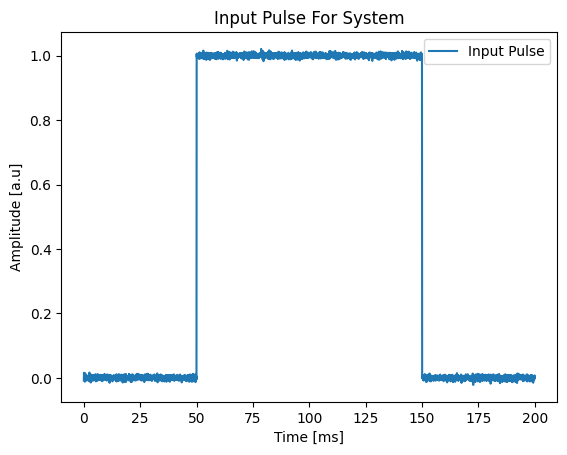

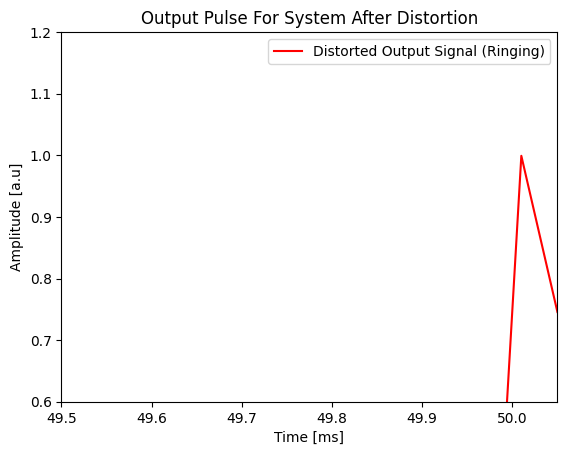

No. of feedbacks is 0 and No. of feedforwards is 3


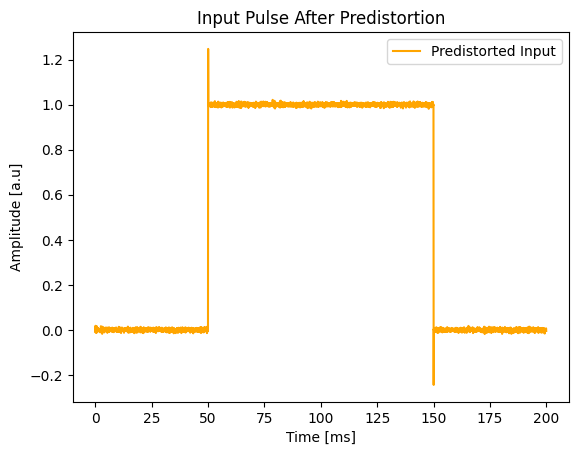

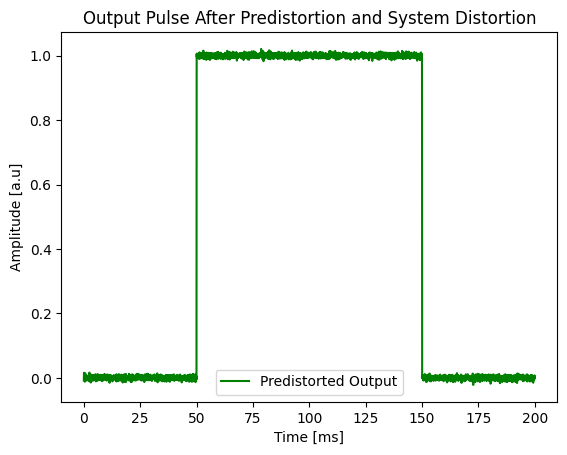

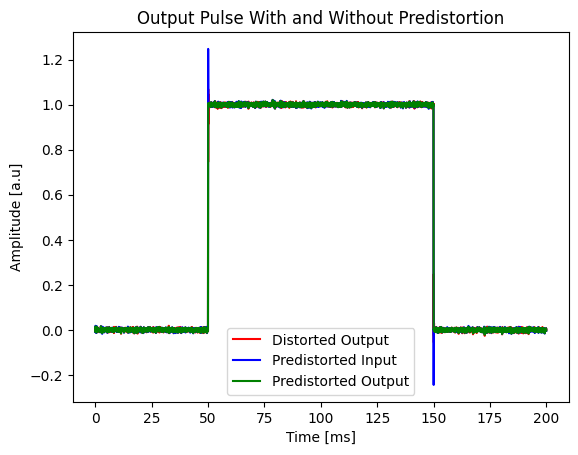

No. of feedbacks is 1 and No. of feedforwards is 3


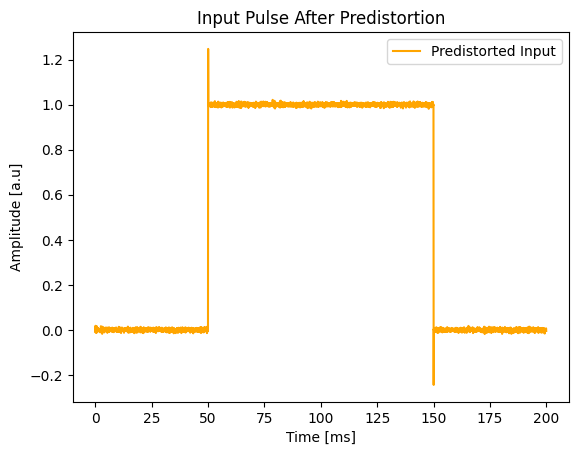

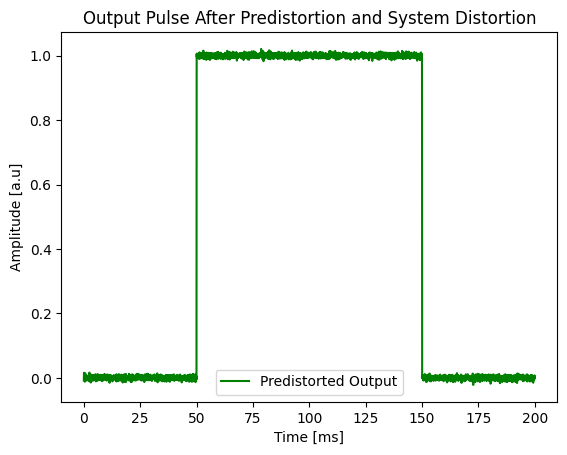

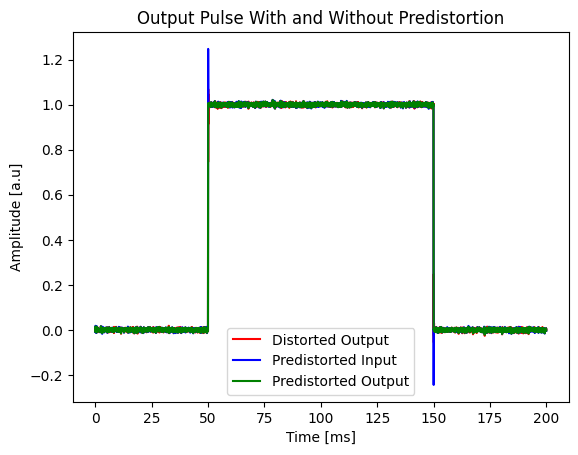

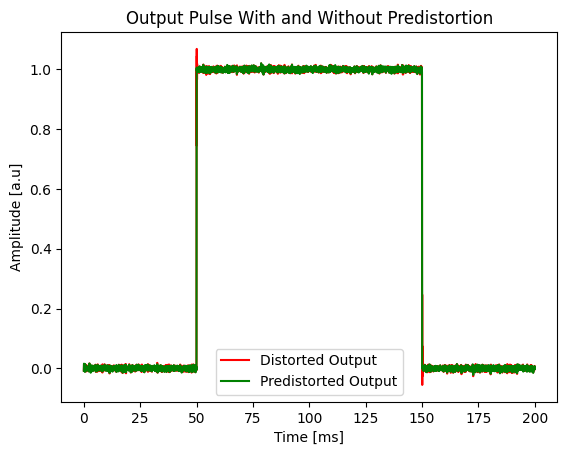

In [171]:
if __name__ == "__main__":

    # user can change the timeframe of the simulation
    # user can decide on the distortion type to simulate and the number of filter taps to be found

    # create the timeframe that the simulation runs for
    # the graphs axis will plot assuming [ms]
    ti = 0
    tf = 200e-3
    tshots = 5000
    time = np.linspace(ti, tf, tshots)
    delta_t = time[1] - time[0]

    input = input_pulse(time) # creates ideal step response
    
    dist_types = ["high-pass", "ringing", "exp"] # types of distortions available
    dist_type = dist_types[1] # choose type this way

    if dist_type == "high-pass":
        # high-pass
        dist_output, system_zeros, system_poles  = high_pass_compensation(time, delta_t, input)

    elif dist_type == "ringing":
        # ringing
        dist_output, system_zeros, system_poles = ringing(time, input)

    elif dist_type == "exp":
        # exponential under/over-shoot
        type = "overshoot" # specify either undershoot or overshoot as a string
        dist_output, system_zeros, system_poles = exp_system_response(time, delta_t, input, type)

    else:
        raise TypeError("Choose a valid distortion type from the list.")

    # Mb is the no. of feedfoward taps in the filter and Ma is the no. of feedback taps
    # one can loop over each amount to see what combination gives the best results
    for Mb in [3]:
        for Ma in [0, 1]:
            print(f"No. of feedbacks is {Ma} and No. of feedforwards is {Mb}")
            dpd_x = filter_correction(input, dist_output, time, Ma, Mb) # pre-distorted signal
            full_correction(dpd_x, time, system_zeros, system_poles) # pre-distorted signal agter system distortion
            all_together(dpd_x, dist_output, time, system_zeros, system_poles)
    if dist_type == "ringing":
        zoomed_in_comparison(dpd_x, dist_output, time, system_zeros, system_poles) # for the ringing plot, one can zoom into the ringing region
            


## Analytical IIR Filter
------------------------

This code section applies a single exponential under/over-shoot distortion. Each exponential mode is fitted to the (1+Ae^-t/tau)u(t) model and the amplitude, A, and the time constant, tau, are extracted. 
Using these parameters and the analytical equation that provides the value of the IIR filter taps that best corrects for this distortion type are found and applied in order to correct the distorted signal towards the step function.

### Generating Exponential
------------------------------

In [73]:
def exp_models(time):

    A = 0.1
    g = 1.0
    tau = 10e-3
    exp_decay = np.heaviside(time, 1.0) * g * (1 + A * np.exp(-time / tau))  # this is an overshoot
    #exp_decay += np.random.normal(0, 1e-3, size = exp_decay.shape) # potential for introducing stochastic noise
    exp_rise = np.heaviside(time, 1.0) * g * (1 - A * np.exp(-time/tau)) # this is an undershoot
    exp_rise += 0.01*np.sin(2*np.pi*time*10)
    #exp_rise += np.random.normal(0, 1e-3, size = exp_rise.shape)

    fig, (ax1, ax2) = plt.subplots(2, sharex = True)

    ax1.plot(time, exp_decay)
    ax1.set_title("Bias Tee Exponential-Overshoot Response")
    ax1.set(ylabel = 'Amplitude [a.u.]')
    ax1.grid(True)

    ax2.plot(time, exp_rise, 'tab:orange')
    ax2.set_title("Bias Tee Exponential-Undershoot Response")
    ax2.set(xlabel = 'Time [ms]', ylabel = 'Amplitude [a.u.]')
    ax2.grid(True)
    
    plt.show()

    return exp_decay, exp_rise

### Fitting Exponential
--------------------------

In [72]:
def exponential_decay_fit(signal, time): # single iir filter

    target = np.ones_like(time)
    def step_exponential(t, A, tau, g):
        return target * (g * (1 + A * np.exp(-t / tau))) 


    # initial guesses
    g0 = 1.0  
    A0 = 0.5   
    tau0 = 20e-3              

    popt, _ = curve_fit(
        step_exponential,
        time,
        signal,
        p0 = [A0, tau0, g0]
    )

    A, tau, g = popt
    print("Fitted Exponential Parameters:")
    print(f"A = {A:.3f}. Expected range: [-1, 1)")
    print(f"tau_IIR = {tau*1e3:.3f} [ms]. Expected range: [6ns, 2ms]")
    print(f"g = {g:.3f}")

    plt.plot(time*1e3, signal, label = 'Original Signal', alpha = 0.7, color = 'red')
    plt.plot(time*1e3, step_exponential(time, *popt), label = 'Fitted Signal', alpha = 0.7, color = 'blue')
    plt.title('Exponential Decay Fit')
    plt.xlabel('Time (ms)')
    plt.ylabel('Amplitude')
    plt.legend()
    plt.grid(True)
    plt.show()

    return A, tau, g

### IIR Tap Finder
----------------------------

In [85]:
def IIR_filter_calc(A, tau, g, delta_t): # single iir filter

    fs = 1 / delta_t
    alpha = 1 - np.exp(-1 / (fs * tau * (1 + A)))

    #if not (0 <= alpha <= 1):
    #    raise ValueError(f"Unstable alpha: {alpha}")

    
    if A < 0:
        k = A / ((1 + A) * (1 - alpha))
    else:
        k = A / (1 + A - alpha)
    
    b0 = 1 - k + (k * alpha)
    b1 = -(1 - k) * (1 - alpha)
    a0 = 1
    a1 = -(1 - alpha)

    feedforward_taps = np.array([b0, b1])
    feedback_taps = np.array([a0, a1])

    bmax = 2 - 2**-20
    highest_b = np.max(np.abs(feedforward_taps))

    amax = 1 - 2**-20
    
    print(f"Feedforward taps: {feedforward_taps}")
    print(f"Feedback taps: {feedback_taps}")

    return feedforward_taps, feedback_taps

In [76]:
def calc_IIR_correction(feedforward_taps, feedback_taps, signal, g): # single iir filter

    iir_correction = lfilter(feedforward_taps, feedback_taps, signal)
    iir_correction /= g  # compensate for gain

    return iir_correction

### FIR Tap Finder
------------------------

In [77]:
def FIR_filter_calc(signal, n_taps): 
    
    x = signal
    N = len(x)

    # desired output is the step function
    u = np.ones(N)
    
    # build convolution matrix
    X = np.zeros((N, n_taps))

    for n in range(N):
        for i in range(n_taps):
            if n - i >= 0:
                X[n, i] = x[n - i]

    # least-squares solution
    b, *_ = np.linalg.lstsq(X, u, rcond=None)

    return b

In [78]:
def FIR_filter_calc_cutoff(signal, n_taps, time): # tau_sweep back for cutoff

    if 2*n_taps > len(signal):
        raise ValueError("Number of taps is too large for the length of the signal and there cannot be a convolution matrix created. Please reduce n_taps.")

    cutoff = time[n_taps]
    mask = time >= cutoff # this is to ensure that the X convolution matrix has no zero entries

    x = signal[mask]
    N = len(x) + 1

    # desired output is the step function
    u = np.ones(N)

    # build convolution matrix
    X = np.zeros((N, n_taps))

    for n in range(N):
        for i in range(n_taps):
                X[n, i] = (signal[n - i + (n_taps - 1)])

    lambda_reg = 10e-4
    XtX = X.T @ X
    
    # least-squares solution
    b = np.linalg.lstsq(X, u, rcond = None)[0]
    #b = np.linalg.lstsq(XtX + lambda_reg * np.eye(n_taps), X.T @ u, rcond = None)[0]

    print("X:", X)
    print("b coefficients:", b)

    return b


In [79]:
def calc_FIR_correction(signal, fir_taps): 

    #fir_correction = np.convolve(signal, fir_taps, mode='full')[:len(signal)]
    fir_correction = lfilter(fir_taps, 1.0, signal)

    return fir_correction

### Plotting
-------------------------

In [81]:
def plot_IIR_results(time, signal, corrected_signal, title):

    plt.figure(figsize=(10, 6))
    plt.plot(time*1e3, signal, label = 'Original Signal', alpha = 0.7, color = 'red')
    plt.plot(time*1e3, corrected_signal, label = 'Corrected Signal', alpha = 0.7, color = 'cyan')
    plt.title(title)
    plt.xlabel('Time (ms)')
    plt.ylabel('Amplitude (a.u)')
    plt.legend()
    plt.grid(True)
    #plt.xlim(0, 20)
    plt.show()

    """plt.figure(figsize=(10, 6))
    plt.plot(time*1e3, signal, label = 'Original Signal', alpha = 0.7, color = 'red')
    plt.plot(time*1e3, corrected_signal, label = 'Corrected Signal', alpha = 0.7, color = 'blue')
    plt.title(title)
    plt.xlabel('Time (ms)')
    plt.ylabel('Amplitude')
    plt.legend()
    plt.grid(True)
    plt.xlim(50, 200)
    plt.show()"""

In [82]:
def plot_full_results(time, signal, iir_correction, fir_correction, title):

    plt.figure(figsize=(10, 6))
    plt.plot(time*1e3, signal, label = 'Original Signal', alpha = 0.7, color = 'red')
    plt.plot(time*1e3, iir_correction, label = 'IIR Corrected Signal', alpha = 0.7, color = 'cyan')
    plt.plot(time*1e3, fir_correction, label = 'IIR + FIR Corrected Signal', alpha = 0.7, color = 'lime')
    plt.title(title)
    plt.xlabel('Time (ms)')
    plt.ylabel('Amplitude (a.u)')
    plt.legend()
    plt.grid(True)
    #plt.xlim(0, 20)
    plt.show()

### Run This User Cell
----------------------------

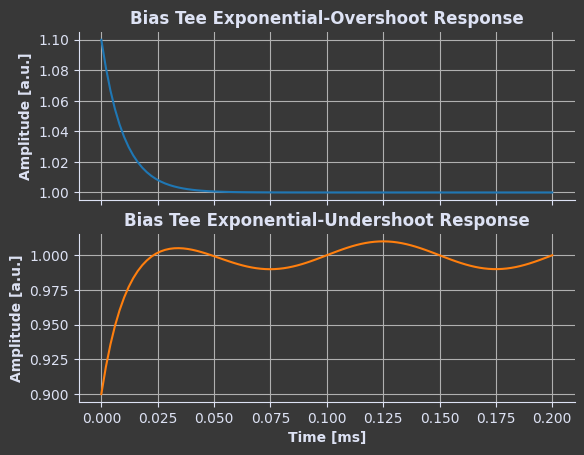

Fitted Exponential Parameters:
A = 0.100. Expected range: [-1, 1)
tau_IIR = 10.000 [ms]. Expected range: [6ns, 2ms]
g = 1.000


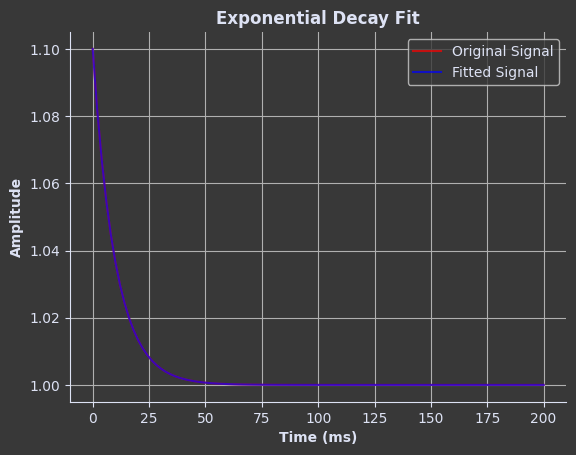

Correcting IIR filter feedback coefficient...
Feedforward taps: [ 0.91072705 -0.74295014]
Feedback taps: [ 0.99999905 -0.8322231 ]


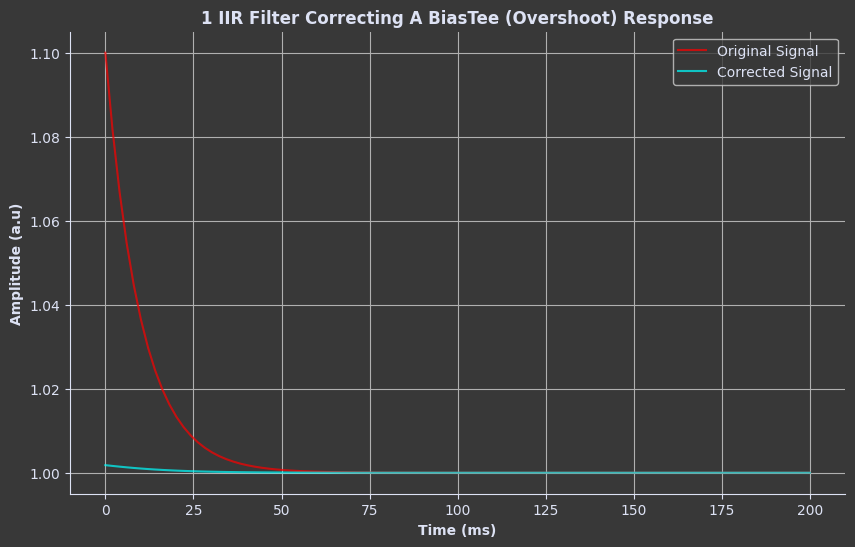

Fitted Exponential Parameters:
A = -0.104. Expected range: [-1, 1)
tau_IIR = 7.314 [ms]. Expected range: [6ns, 2ms]
g = 0.999


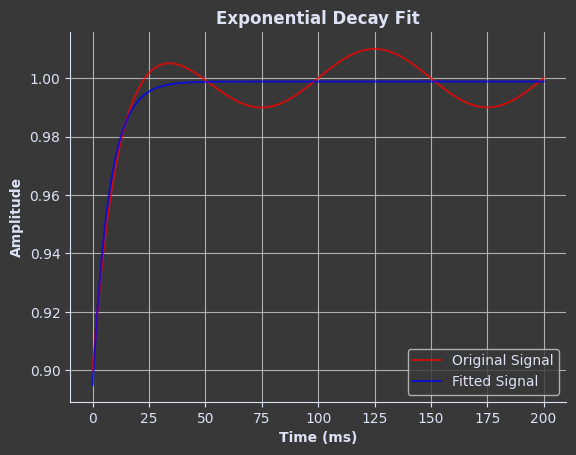

Correcting IIR filter feedback coefficient...
Feedforward taps: [ 1.1160044  -0.85074204]
Feedback taps: [ 0.99999905 -0.73473764]


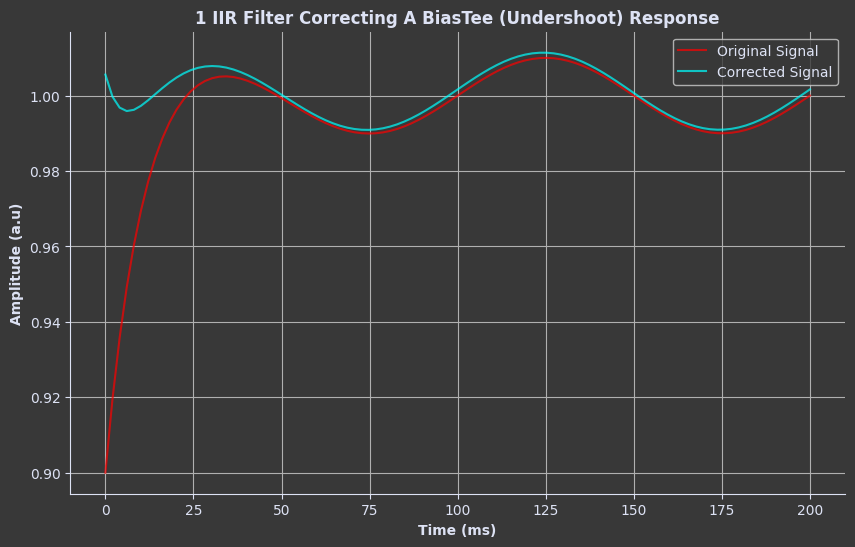

In [84]:
if __name__ == "__main__":
    nshots = 100
    ti = 0
    tf = 200e-3
    time = np.linspace(ti, tf, nshots)
    delta_t = time[1] - time[0]
    exp_overshoot, exp_undershoot = exp_models(time)

    A, tau, g = exponential_decay_fit(exp_overshoot, time)
    feedforward_taps, feedback_taps = IIR_filter_calc(A, tau, g, delta_t)
    iir_correction = calc_IIR_correction(feedforward_taps, feedback_taps, exp_overshoot, g)
    plot_IIR_results(time, exp_overshoot, iir_correction, '1 IIR Filter Correcting A BiasTee (Overshoot) Response')

    A, tau, g = exponential_decay_fit(exp_undershoot, time)
    feedforward_taps, feedback_taps = IIR_filter_calc(A, tau, g, delta_t)
    iir_correction2 = calc_IIR_correction(feedforward_taps, feedback_taps, exp_undershoot, g)
    plot_IIR_results(time, exp_undershoot, iir_correction2, '1 IIR Filter Correcting A BiasTee (Undershoot) Response')


    """n_taps = 28
    b = FIR_filter_calc(iir_correction, n_taps)
    fir_correction = calc_FIR_correction(iir_correction, b)
    plot_full_results(time, exp_overshoot, iir_correction, fir_correction, '1 FIR Filter Correcting A BiasTee (Overshoot) Response')

    b = FIR_filter_calc(iir_correction2, n_taps)
    fir_correction = calc_FIR_correction(iir_correction2, b)
    plot_full_results(time, exp_undershoot, iir_correction2, fir_correction, f'IIR + FIR Filter with {n_taps} Taps Correcting A BiasTee (Undershoot) Response')"""



## Multiple Exponential Modes
-------------------------------
This does the same as before but applies a cascade of exponential distortions, rather than just one. Therefore, it also uses more than one IIR filter to correct.

### Generating Exponentials
-------------------------

In [63]:
def multiple_exp_modes(time, modes, delta_t, type):

    
    if type == 'overshoot':
        As = np.random.uniform(0.05, 0.95 / modes, size = modes)
    elif type == 'undershoot':
        As = np.random.uniform(-0.95 / modes, -0.05, size = modes)
    else:
        As = np.random.uniform(-0.95 / modes, 0.95 / modes, size = modes)
        
    taus = np.random.uniform(5*delta_t, 50*delta_t, size = modes)
    g = 1.0

    exp_response = np.ones_like(time)
    for Ak, tauk in zip(As, taus):
        exp_response += Ak * np.exp(-time / tauk)
    
    exp_response = g * exp_response 
    exp_response += np.random.normal(0, 0.5e-3, size = exp_response.shape)

    plt.plot(time*1e3, exp_response)
    plt.title(f"{modes}-Mode Exponential Bias Tee Response")
    plt.xlabel("Time [ms]")
    plt.ylabel("Amplitude [a.u.]")
    plt.grid(True)
    plt.show()

    return exp_response

### Fitting Exponentials
---------------------------

In [64]:
def multi_exponential_mode_fit(signal, time, n_iir):
    
    def exp_model(t, *params):
        A = params[:n_iir]
        tau = params[n_iir:-1]
        g = params[-1]

        s = np.ones_like(t)
        for Ak, tauk in zip(A, tau):
            s += Ak * np.exp(-t / tauk)

        return g * s

    # initial guesses
    A0 = np.full(n_iir, 0.5)
    tau0 = np.logspace(
        -4,
        -1, 
        n_iir
    )
    g0 = 1.0

    p0 = np.concatenate([A0, tau0, [g0]])

    lower_bounds = np.concatenate([
    np.full(n_iir, -0.99),      # A > -1
    np.full(n_iir, 10e-6),       # tau > 1us 
    [0.0]                       # g > 0
    ])

    upper_bounds = np.concatenate([
    np.full(n_iir, 0.99),        # A < 1
    np.full(n_iir, 1.0),        # tau < 1s
    [np.inf]
    ])

    popt, _ = curve_fit(
        exp_model,
        time,
        signal,
        p0=p0,
        bounds=(lower_bounds, upper_bounds),
        maxfev = 20000000
    )

    A_list = popt[:n_iir]
    tau_list = popt[n_iir:-1]
    g = popt[-1]

    """print("Fitted Multi Exponential Rise Parameters:")
    for i, (A, tau) in enumerate(zip(A_list, tau_list)):
        print(f"  A{i+1} = {A:.3f} with expected range [-1, 1), \n tau{i+1} = {tau*1e3:.3f} [ms] with expected range (6ns, 3ms).")
    print(f"g = {g:.3f}")

    print("A length: ", len(A_list)); print("tau length: ", len(tau_list))"""

    # fitted forward response (diagnostic)
    fit_full = exp_model(time, *popt)

    plt.plot(time*1e3, signal, label = 'Original Signal', alpha = 0.7, color = 'red')
    plt.plot(time*1e3, fit_full, label = 'Multi-Fitted Signal', alpha = 0.7, color = 'blue')
    plt.title('Multiple-Exponential Model Fit')
    plt.xlabel('Time [ms]')
    plt.ylabel('Amplitude [a.u.]')
    plt.legend()
    plt.grid(True)
    plt.show()

    return A_list, tau_list, g


### IIR Filter Tap Finder
----------------------------

In [65]:
def IIR_filter_calc_multi(A_list, tau_list, delta_t): # each iir filter is dedicated to correcting an exponential mode

    fs = 1 / delta_t
    b_list = []
    a_list = []

    for A, tau in zip(A_list, tau_list):

        alpha = 1 - np.exp(-1 / (fs * tau * (1 + A))) 

        if A < 0:
            k = A / ((1 + A) * (1 - alpha))
        else:
            k = A / (1 + A - alpha)

        b = np.array([
            1 - k + (k * alpha),
            -(1 - k) * (1 - alpha)
        ])

        a = np.array([
            1,
            -(1 - alpha)
        ])

        b_list.extend(b)
        a_list.extend(a)

       
    b_tot = np.array(b_list)
    a_tot = np.array(a_list)

    bmax = 2 - 2**-16
    highest_b = np.max(np.abs(b_tot))

    amax = 1 - 2**-16

    if highest_b > bmax:
        #print("Correcting IIR filter feedforward coefficient...")
        b_tot = 2 * b_tot / highest_b

    if np.any(np.abs(a_tot)) > amax:
        #print("Correcting IIR filter feedback coefficient...")
        a_tot[a_tot > amax] = amax
        a_tot[a_tot < -amax] = -amax

    #print(f"Feedforward taps: {b_tot}")
    #print(f"Feedback taps: {a_tot}")

    return b_tot, a_tot


In [66]:
def calc_multi_IIR_correction(b_tot, a_tot, signal):

    iir_correction = signal.copy()

    for i in range(0, len(b_tot), 2):
        b = b_tot[i:i+2]
        a = a_tot[i:i+2]
        #print(f"Current b coeffs: {b} ")
        iir_correction = lfilter(b, a, iir_correction)

    iir_correction = np.divide(iir_correction, np.mean(iir_correction)) # normalise result

    return iir_correction

In [67]:
def residual_correction(signal, corrected_signal):

    mse = np.mean((signal - corrected_signal) ** 2)
    #print(f"Mean Squared Error of Correction: {mse:.6e}")
    
    return mse

### Plotting
-------------------

In [68]:
def plot_multi_mode_results(time, signal, corrected_signal, n_iir, modes):

    plt.figure(figsize=(10, 6))
    plt.plot(time*1e3, signal, label = 'Original Signal', alpha = 0.7, color = 'red')
    plt.plot(time*1e3, corrected_signal, label = 'Corrected Signal', alpha = 0.7, color = 'cyan')
    plt.title(f"{n_iir} IIR Filter Correction to a {modes}-Mode Exponential Bias Tee Response")
    plt.xlabel('Time [ms]')
    plt.ylabel('Amplitude [a.u.]')
    plt.legend()
    plt.grid(True)
    #plt.xlim(0, 20)
    plt.show()

### Run This User Cell
-------------------------

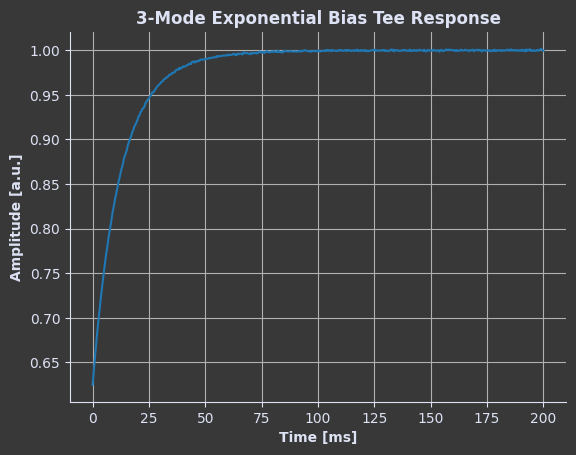

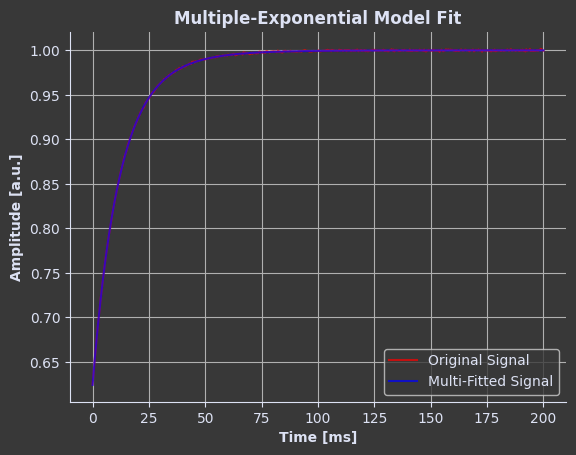

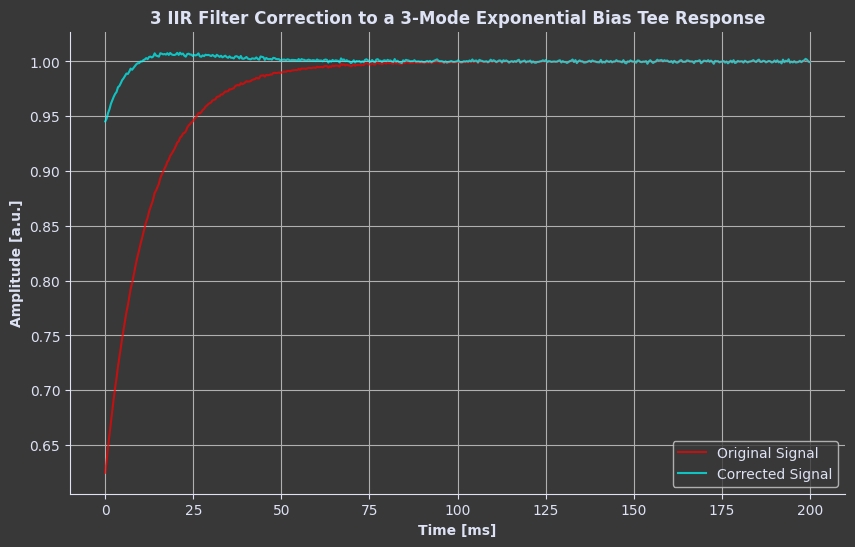

Number of IIR modes: 3, MSE: 3.997170e-03
Best correction achieved with 3 IIR modes.


In [40]:
if __name__ == "__main__":
    nshots = 500
    ti = 0
    tf = 200e-3
    time = np.linspace(ti, tf, nshots)
    delta_t = time[1] - time[0]
    modes = 3
    exp_response = multiple_exp_modes(time, modes, delta_t, type = 'undershoot')
    MSEs = []
    n_iir_list = [modes]
    for n_iir in n_iir_list:
        A_list, tau_list, g = multi_exponential_mode_fit(exp_response, time, n_iir)
        b_tot, a_tot = IIR_filter_calc_multi(A_list, tau_list, delta_t)
        iir_correction = calc_multi_IIR_correction(b_tot, a_tot, exp_response)
        plot_multi_mode_results(time, exp_response, iir_correction, n_iir, modes)
        mse = residual_correction(exp_response, iir_correction)
        print(f"Number of IIR modes: {n_iir}, MSE: {mse:.6e}")
        if not np.isnan(mse):
            MSEs.append(mse)
    best = np.argmin(MSEs)
    print(f"Best correction achieved with { n_iir_list[best] } IIR modes.")